<a href="https://colab.research.google.com/github/nathancowieson/SAXSColab/blob/main/FOXS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1) INSTALL FOXS SAXS CALCULATOR
The following cells step through installing the FOXS SAXS calculator so that it is available through Colab. The instructions that we will follow can be found [here](https://integrativemodeling.org/download-linux.html), the process will rely on third-party libraries and may fail if there have been changes, try it as is at first but if you are having problems it may be that you can find what has changed and fix it yourself.

In [ ]:
import re
from IPython.display import display, Markdown

def error_message(message=""):
  message = '<font color="red"><h3>'+str(message)+'</h3></font>'
  display(Markdown(message))
def info_message(message=""):
  message = '<font color="green"><h3>'+str(message)+'</h3></font>'
  display(Markdown(message))

#@title 1.1) Check Linux Version
success_1 = False
linux_type = 'Unknown'
linux_version = 'Unknown'
version_info=!cat /etc/os-release
version_pattern = re.compile('^VERSION_ID=.*')
type_pattern = re.compile('^NAME=.*')
for line in version_info:
  if re.match(version_pattern, line):
    try:
      linux_version = float(eval(line.split('=')[-1]))
    except:
      pass
  elif re.match(type_pattern, line):
    linux_type = eval(line.split('=')[-1])
  else:
    pass

if 'Unknown' in [linux_type, linux_version]:
  success_1 = False
  error_message('Failed to get Linux version or type, may cause issues')
else:
  info_message(f'Running {linux_type} version {linux_version}.')
  success_1 = True


<font color="green"><h3>Running Ubuntu version 20.04.</h3></font>

In [ ]:
#@title 1-2) Find appropriate Salilab software repository
success_2 = True
repository_string = "deb https://integrativemodeling.org/latest/download bionic/\n"
if linux_type == 'Ubuntu':
  if type(linux_version) == float:
    if linux_version > 20.0:
      print(f'version {linux_version}')
      repository_string = "deb https://integrativemodeling.org/latest/download focal/\n"
    elif linux_version < 18.0:
      error_message(f'This version of Ubuntu is not supported')
      success_2 = False
    else:
      pass
  else:
    error_message('Lack of linux version number could cause problems')
    success_2 = False
else:
  error_message('Only Ubuntu is currently supported')
  success_2 = False

sources_file = '/etc/apt/sources.list'
resource_exists = False
pattern = re.compile(f'^{repository_string}$')
with open(sources_file, 'r') as f:
  for line in f.readlines():
    if re.match(pattern, line):
      resource_exists = True
if resource_exists:
  info_message('The repository is already in the sources file')
else:
  info_message('Added repository to the sources file')
  with open(sources_file, 'a') as f:
    f.write(repository_string)


version 20.04


<font color="green"><h3>Added repository to the sources file</h3></font>

In [ ]:
#@title 1-3) Install FOXS SAXS calculator
#@markdown The instructions for installing IMP/FOXS change from time to time and you may have to tweak this section if it does not work. You'll find the find the signing key on the IMP/Foxs installation page [here](https://integrativemodeling.org/download-linux.html)).
def foxs_exists():
  s = !which foxs
  if len(s) == 0:
    return False
  else:
    return True

if not foxs_exists():
  if success_2:
    #Get the signing key
    !sudo wget -O /etc/apt/trusted.gpg.d/salilab.asc https://salilab.org/~ben/pubkey256.asc
    #Make sure apt-get has latest info
    !apt-get update
    #Install software
    info_message('Installing IMP/Foxs, might take a minute')
    !apt-get install imp
  else:
    error_message('Could not install FOXS without repository info from step 2')
else:
  info_message('Foxs was already installed, will do nothing')

try:
  s = !foxs --version
  foxs_version = eval(re.split(':| ',s[0])[-1])
  info_message(f'We are now running Foxs version {foxs_version}')
except:
  error_message('We do not have a working version of Foxs')


--2023-06-06 08:10:18--  https://salilab.org/~ben/pubkey256.asc
Resolving salilab.org (salilab.org)... 169.230.79.19
Connecting to salilab.org (salilab.org)|169.230.79.19|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3122 (3.0K) [text/plain]
Saving to: ‘/etc/apt/trusted.gpg.d/salilab.asc’

/etc/apt/trusted.gp 100%[===================>]   3.05K  --.-KB/s    in 0s      

2023-06-06 08:10:19 (560 MB/s) - ‘/etc/apt/trusted.gpg.d/salilab.asc’ saved [3122/3122]

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu focal-cran40/ InRelease [3,622 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu focal-cran40/ Packages [78.0 kB]
Get:4 http://security.ubuntu.com/ubuntu focal-security InRelease [114 kB]
Hit:5 http://archive.ubuntu.com/ubuntu focal InRelease
Get:6 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu focal InRelease [18.1 kB]
Get:7 https://integrativemodeling.or

<font color="green"><h3>Installing IMP/Foxs, might take a minute</h3></font>

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  libgsl23 libgslcblas0 python3-numpy python3-protobuf
Suggested packages:
  gsl-ref-psdoc | gsl-doc-pdf | gsl-doc-info | gsl-ref-html python-numpy-doc
  python3-pytest python3-numpy-dbg
The following NEW packages will be installed:
  imp libgsl23 libgslcblas0 python3-numpy python3-protobuf
0 upgraded, 5 newly installed, 0 to remove and 49 not upgraded.
Need to get 54.4 MB of archives.
After this operation, 465 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/universe amd64 libgslcblas0 amd64 2.5+dfsg-6build1 [84.6 kB]
Get:2 https://integrativemodeling.org/latest/download focal/ imp 2.18.0-1 [50.4 MB]
Get:3 http://archive.ubuntu.com/ubuntu focal/universe amd64 libgsl23 amd64 2.5+dfsg-6build1 [850 kB]
Get:4 http://archive.ubuntu.com/ubuntu focal-updates/main amd64 python3-numpy amd64 1:1.17.4-5ubuntu3.1

<font color="green"><h3>We are now running Foxs version 2.18.0</h3></font>

# 2) Get PDB files
The following three sections provide some tools for getting PDB files.

In [ ]:
#@title 2-1) From the PDB database via an ID code
link_address = None
#@markdown (4F5S is BSA)
pdb_code = '4f5S' #@param {type:"string"}
pdb_code = pattern.sub('',pdb_code.upper())#Strip non-alphanum characters
if not len(pdb_code) == 4:
  error_message('PDB codes should be 4 character alpha-numberical strings.')
else:
  link_address=f'https://files.rcsb.org/download/{pdb_code.upper()}.pdb'

#@markdown If you leave output_file blank we'll use the pdb_code as the output name (i.e. 4F5S.pdb).
output_file = '' #@param {type:"string"}

if output_file == '':
  output_file = f'{pdb_code}.pdb'
elif len(output_file) >3:
  if not output_file[-4:] == '.pdb':
    output_file = f'{output_file}.pdb'
else:
  output_file = f'{output_file}.pdb'
info_message(f'Will use output file: {output_file}')

def file_exists(filename):
  filelist = !ls -l | grep {output_file}
  if len(filelist) == 0:
    return False
  else:
    return True

if file_exists(output_file):
  print(f'Output file: {output_file} already exists, will overwrite')
  !rm {output_file}
!wget {link_address} -o {output_file}
if file_exists(output_file):
  info_message(f'Successfully downloaded {pdb_code} as {output_file}')



<font color="green"><h3>Will use output file: 4F5S.pdb</h3></font>

<font color="green"><h3>Successfully downloaded 4F5S as 4F5S.pdb</h3></font>

In [ ]:
import ipywidgets as widgets
from IPython.display import display
#@title 2-2) Upload one or more PDB file from a local drive
pdbfiles = widgets.FileUpload()
display(pdbfiles)
uploaded_files = pdbfiles.value.keys()
def on_upload_change(change):
    for fn in pdbfiles.value.keys():
        with open(fn, 'w') as f:
            f.write(pdbfiles.value[fn]['content'].decode('utf-8'))
    info_message(f'{len(pdbfiles.value.keys())} files uploaded: {", ".join(pdbfiles.value.keys())}')
pdbfiles.observe(on_upload_change, names='_counter')

FileUpload(value={}, description='Upload')

In [ ]:
#@title 2-3) Get tutorial data from Google Drive
#@markdown The tutorial data is composed of some pdb files and some dat files that are the monomer and dimer forms of BSA. These will be stored in a subdirectory call 'FOXS_tutorial_data'.

import os.path
tutorial_files = {'dimer_chainA.pdb': '1KsUNCKSr-Fv-UYl7GMXaXjm7C2V9-agB',
                  'dimer_chainB.pdb': '1BfV6K26jzswvtoxhUdoyqxyPGVuThULL',
                  'dimer.dat': '1IrtZwKTSaQmE8zdVodLvGnHkuHYtVF8g',
                  'dimer.pdb': '18AxCgzRAVxCW8YuA2h_cRxau50DvCBew',
                  'monomer.dat': '1xgoGSu29yLbt2S4XnVZzZjQ5lltF6YRa',
                  'monomer.pdb': '16LQNFFfeZuHDcPrJkolvshgCV20MYJUo'
                  }
output_dir = 'FOXS_tutorial_data'
if not os.path.isdir(output_dir):
    !mkdir {output_dir}
for k, v in tutorial_files.items():
    url = 'https://drive.google.com/uc?id={}'.format(v)
    !wget -q -O {output_dir}/{k} {url}
success=True
for k in tutorial_files.keys():
    if not os.path.isfile(f'{output_dir}/{k}'):
        success=False
if success:
    info_message(f'Successfully downloaded tutorial files')
else:
    error_message('Failed to get tutorial files')
!ls -l {output_dir}



NameError: ignored

### VISUALISE THE PDB

In [ ]:
!pip install py3Dmol

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import py3Dmol

In [ ]:
view=py3Dmol.view()
view.addModel(open('FOXS_tutorial_data/dimer.pdb', 'r').read(),'pdb')
view.zoomTo()
view.setBackgroundColor('white')
view.setStyle({'chain':'A'},{'cartoon': {'color':'green'}})
view.setStyle({'chain':'B'},{'cartoon': {'color':'blue'}})
view.show()

FileNotFoundError: ignored

# Upload a DAT file from a local drive
Upload a DAT file containing your SAXS data from your local file system

In [ ]:
#@title Upload a DAT file from a local drive
datfiles = widgets.FileUpload()
display(datfiles)
uploaded_files = datfiles.value.keys()
def on_upload_change(change):
  info_message(f'{len(datfiles.value.keys())} files uploaded: {", ".join(datfiles.value.keys())}')
datfiles.observe(on_upload_change, names='_counter')

FileUpload(value={}, description='Upload')

<font color="green"><h3>1 files uploaded: dimer.dat</h3></font>

In [ ]:
with open('dimer.dat', 'w') as f:
    f.write(datfiles.value['dimer.dat']['content'].decode('utf-8'))

### SOME SCRIPTS FOR INTERACTING WITH PDB AND DAT FILES, RUNNING FOXS AND PARSING OUTPUT

In [ ]:
!pip install b21scripts

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import b21scripts.readwrite.dat
import os

In [ ]:
#os.chdir('./FOXS_tutorial_data')
job = b21scripts.readwrite.dat.DAT('dimer.dat')

[2023-06-07 11:12:30]: INFO: readwrite.DAT: Starting a new readwrite.DAT job
INFO:readwrite.DAT:Starting a new readwrite.DAT job
[2023-06-07 11:12:30]: INFO: readwrite.DAT: dimer.dat lookks like a valid datfile
INFO:readwrite.DAT:dimer.dat lookks like a valid datfile
[2023-06-07 11:12:30]: INFO: readwrite.DAT: Reading and parsing dat file: dimer.dat
INFO:readwrite.DAT:Reading and parsing dat file: dimer.dat
[2023-06-07 11:12:30]: INFO: readwrite.DAT: Calculated high Q window in Q range: 0.23278644:0.26965744
INFO:readwrite.DAT:Calculated high Q window in Q range: 0.23278644:0.26965744
[2023-06-07 11:12:30]: INFO: readwrite.DAT: Calculated low Q window in Q range: 0.011168161:0.021235776
INFO:readwrite.DAT:Calculated low Q window in Q range: 0.011168161:0.021235776
[2023-06-07 11:12:30]: INFO: readwrite.DAT: Parsed with 2567 data points.
INFO:readwrite.DAT:Parsed with 2567 data points.


In [ ]:
import b21scripts.saxs.saxs_calc

In [ ]:
os.chdir('./FOXS_tutorial_data')
job = b21scripts.saxs.saxs_calc.SaxsCalc()

[2023-06-06 08:15:39]: INFO: saxs_calc: Starting a new SaxsCalc job
INFO:SaxsCalc:Starting a new SaxsCalc job


In [ ]:
job.AddPdbFile('dimer.pdb')

[2023-06-06 08:15:55]: INFO: saxs_calc: Added pdb file dimer.pdb
INFO:SaxsCalc:Added pdb file dimer.pdb


True

In [ ]:
job.AddDatFile('dimer.dat')

[2023-06-06 08:16:05]: INFO: saxs_calc: Added dat file dimer.dat
INFO:SaxsCalc:Added dat file dimer.dat


True

In [ ]:
job.RunFoxs()

[2023-06-06 08:16:10]: INFO: saxs_calc: Running FoXS
INFO:SaxsCalc:Running FoXS


True

[2023-06-06 08:16:18]: INFO: saxs_calc: Plotting the data
INFO:SaxsCalc:Plotting the data


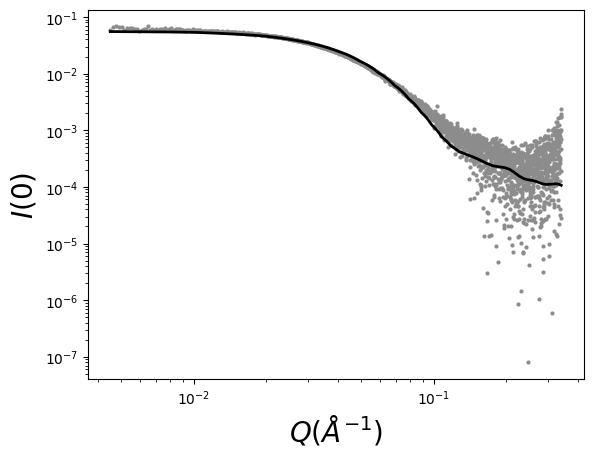

In [ ]:
job.PlotTheFit()

In [ ]:
job.OutputChiScore()

[2023-06-06 08:16:22]: INFO: saxs_calc: Chi score is: 8.083
INFO:SaxsCalc:Chi score is: 8.083


'8.083'

### Data does not fit, try moving the two molecules around a bit

In [ ]:
import b21scripts.readwrite.pdb as pdb

In [ ]:
mol1 = pdb.PDB('dimer_chainA.pdb')
mol1.parse_file()
mol2 = pdb.PDB('dimer_chainB.pdb')
mol2.parse_file()


[2023-06-06 09:37:18]: INFO: readwrite.PDB: Reading and parsing pdb file: dimer_chainA.pdb
INFO:readwrite.PDB:Reading and parsing pdb file: dimer_chainA.pdb
[2023-06-06 09:37:18]: INFO: readwrite.PDB: Reading and parsing pdb file: dimer_chainB.pdb
INFO:readwrite.PDB:Reading and parsing pdb file: dimer_chainB.pdb


In [ ]:
output=[]
mol1 = pdb.PDB('dimer_chainA.pdb')
mol1.parse_file()
for x in [0,2,4,6]:
    mol2 = pdb.PDB('dimer_chainB.pdb')
    mol2.parse_file()
    mol2.Translate(f'{x},0,0')
    with open('moving_dimer.pdb', 'w') as p:
        p.write(mol1.return_file(justatoms=True))
        p.write(mol2.return_file(justatoms=True))
    job = b21scripts.saxs.saxs_calc.SaxsCalc()
    job.AddPdbFile('moving_dimer.pdb')
    job.AddDatFile('dimer.dat')
    job.RunFoxs()
    output.append((x, job.OutputChiScore()))

print(output)

[2023-06-06 10:30:48]: INFO: readwrite.PDB: Reading and parsing pdb file: dimer_chainA.pdb
INFO:readwrite.PDB:Reading and parsing pdb file: dimer_chainA.pdb
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Reading and parsing pdb file: dimer_chainB.pdb
INFO:readwrite.PDB:Reading and parsing pdb file: dimer_chainB.pdb
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Translating by 0.0x0.0x0.0
INFO:readwrite.PDB:Translating by 0.0x0.0x0.0
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Writing out a formatted PDB file
INFO:readwrite.PDB:Writing out a formatted PDB file
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Will only return the atom lines
INFO:readwrite.PDB:Will only return the atom lines
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Writing out a formatted PDB file
INFO:readwrite.PDB:Writing out a formatted PDB file
[2023-06-06 10:30:49]: INFO: readwrite.PDB: Will only return the atom lines
INFO:readwrite.PDB:Will only return the atom lines
[2023-06-06 10:30:50]: INFO: saxs_calc: Starting a new Sa

[(0, '8.056'), (2, '6.574'), (4, '5.212'), (6, '4.138')]
